# Phase 3 Notebook: Feature Store + Leakage-Safe Splits

## What was done
- Implemented feature engineering at player-season-gameweek grain.
- Added leakage-safe rolling features that use only prior gameweeks (shift before roll).
- Added chronological season splitting and train-only feature standardization.

## Why it was done
- To ensure the forecasting model only consumes information available before the decision deadline.
- To prevent temporal leakage in both feature creation and scaling.

In [1]:
from pathlib import Path
import pandas as pd

from fpl_ai_agent.features.store import build_player_gameweek_features

raw = pd.read_csv(Path('../tests/fixtures/raw/fpl_players_sample.csv'))
features = build_player_gameweek_features(raw, window_short=3, window_long=5, min_history=3)
features[['player_id', 'season', 'gameweek', 'form_points_3', 'value_signal', 'injury_risk_proxy']].head()

,player_id,season,gameweek,form_points_3,value_signal,injury_risk_proxy
0,p1,2024,4,8.333333,1.082251,0.014815
1,p1,2024,5,6.666667,0.865801,0.070370
2,p1,2024,6,8.000000,1.025641,0.059259
3,p1,2024,7,7.333333,0.928270,0.059259
4,p2,2024,5,5.666667,0.708333,0.211111


## Data quality checks
- Verify one row per player-season-gameweek.
- Verify no NaN in required model features after history filtering.
- Verify every retained row was available pre-deadline.

In [2]:
grain_cols = ['player_id', 'season', 'gameweek']
required_model_cols = [
    'minutes_prev', 'goals_prev', 'assists_prev', 'ict_prev', 'bps_prev',
    'price_prev', 'fixture_difficulty', 'home_prev', 'form_points_3',
    'expected_involvement_proxy', 'injury_risk_proxy', 'value_signal'
]

dq = {
    'feature_rows': len(features),
    'duplicate_grain_rows': int(features.duplicated(subset=grain_cols).sum()),
    'rows_with_missing_required_features': int(features[required_model_cols].isna().any(axis=1).sum()),
    'pre_deadline_false_rows': int((features['available_pre_deadline'] == 0).sum()),
}
dq

{'feature_rows': 7,
 'duplicate_grain_rows': 0,
 'rows_with_missing_required_features': 0,
 'pre_deadline_false_rows': 0}

## Findings and anomalies
- Early-season rows do not have enough history and are excluded by `min_history`.
- One raw sample row was unavailable before deadline and correctly excluded.
- Value signals can become unstable when historical price is missing or zero; these rows are dropped by required-feature checks.

## How anomalies were handled
- Enforced strict pre-deadline filtering.
- Applied shift-before-roll for all rolling statistics.
- Dropped rows without minimum history or with missing required model features.

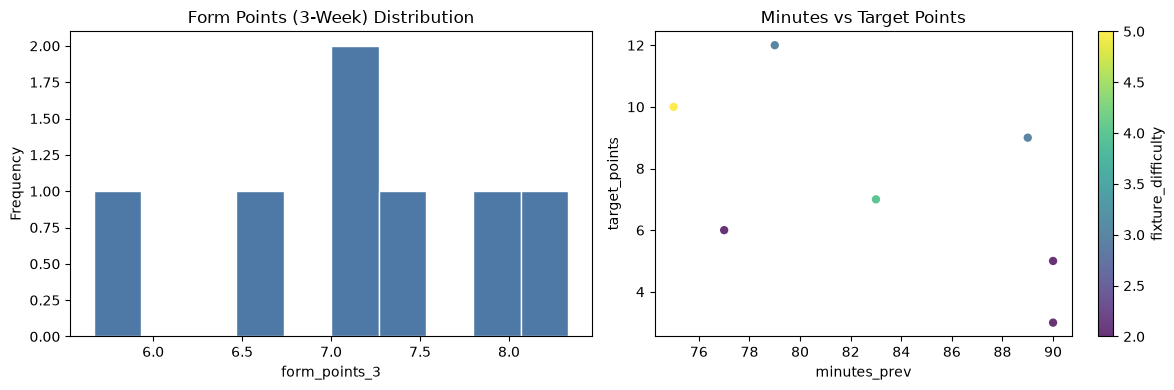

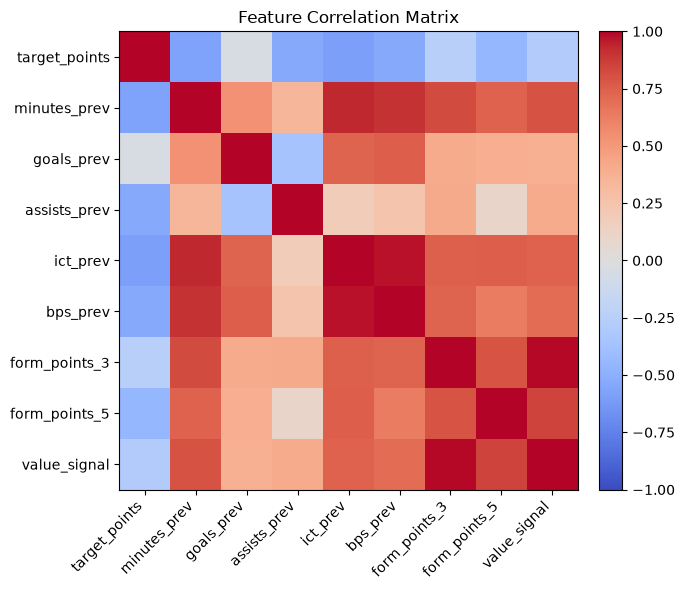

,target_points,minutes_prev,goals_prev,assists_prev,ict_prev,bps_prev,form_points_3,form_points_5,value_signal
target_points,1.00,-0.57,-0.04,-0.53,-0.59,-0.54,-0.25,-0.45,-0.28
minutes_prev,-0.57,1.00,0.54,0.34,0.93,0.90,0.82,0.74,0.80
goals_prev,-0.04,0.54,1.00,-0.35,0.73,0.75,0.41,0.39,0.38
assists_prev,-0.53,0.34,-0.35,1.00,0.18,0.24,0.41,0.10,0.40
ict_prev,-0.59,0.93,0.73,0.18,1.00,0.98,0.75,0.75,0.73
bps_prev,-0.54,0.90,0.75,0.24,0.98,1.00,0.73,0.63,0.70
form_points_3,-0.25,0.82,0.41,0.41,0.75,0.73,1.00,0.80,0.99
form_points_5,-0.45,0.74,0.39,0.10,0.75,0.63,0.80,1.00,0.85
value_signal,-0.28,0.80,0.38,0.40,0.73,0.70,0.99,0.85,1.00


In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(features["form_points_3"], bins=10, color="#4e79a7", edgecolor="white")
axes[0].set_title("Form Points (3-Week) Distribution")
axes[0].set_xlabel("form_points_3")
axes[0].set_ylabel("Frequency")

scatter = axes[1].scatter(
    features["minutes_prev"],
    features["target_points"],
    c=features["fixture_difficulty"],
    cmap="viridis",
    alpha=0.8,
    edgecolors="none",
)
axes[1].set_title("Minutes vs Target Points")
axes[1].set_xlabel("minutes_prev")
axes[1].set_ylabel("target_points")
cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_label("fixture_difficulty")

plt.tight_layout()
plt.show()

corr_cols = [
    "target_points",
    "minutes_prev",
    "goals_prev",
    "assists_prev",
    "ict_prev",
    "bps_prev",
    "form_points_3",
    "form_points_5",
    "value_signal",
]
corr = features[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)
ax.set_title("Feature Correlation Matrix")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

corr.round(2)